# Problem Statement
The objective of this project is to analyze hospital days and build a machine learning model that predicts the length  of stays (in days) for a patient based on various features such as hospital type, admission type, severity of illness, age, and other related factors.

## Business Objective
1. Optimize hospital resource allocation
2. Improve bed management
3. Enhance patient care planning

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [3]:
df_original = pd.read_csv("HealthCareAnalytics.csv")
df_original

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,Nov-20
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,Nov-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,Nov-20,3761,Nov-20


In [4]:
df = df_original.copy()

In [5]:
df.head()
df.info()        
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

### Key Observations
1. Dataset contains both categorical and numerical features
2. Missing values present in Bed Grade and City_code_patient
3. Target variable stay is categorical and needs conversion

### EDA

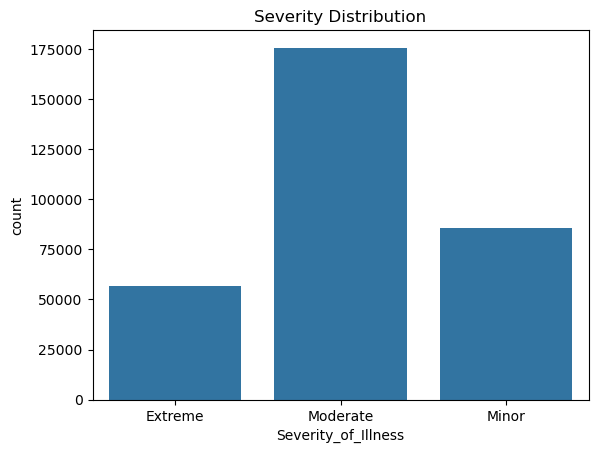

In [8]:
# 1. Severity Distribution
sns.countplot(x = 'Severity_of_Illness', data = df_original)
plt.title('Severity Distribution')
plt.show()

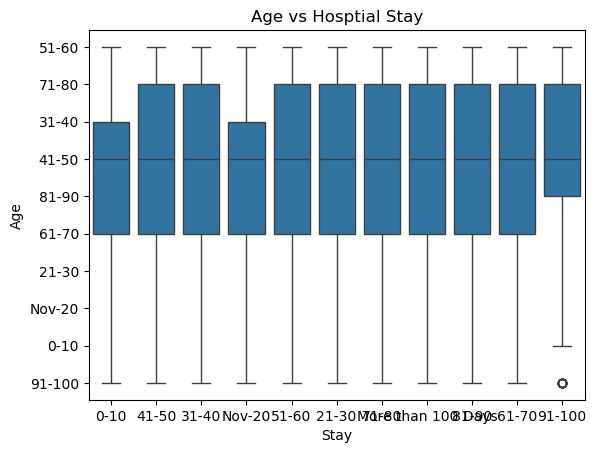

In [9]:
# - Age vs Stay
sns.boxplot(x = 'Stay', y = 'Age', data = df_original)
plt.title('Age vs Hosptial Stay')
plt.show()

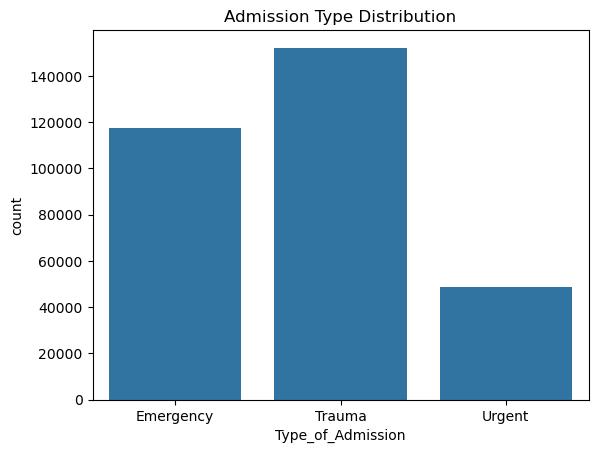

In [10]:
# - Admission Type
sns.countplot(x = 'Type_of_Admission', data = df_original)
plt.title("Admission Type Distribution")
plt.show()

### EDA Insights
1. Patients with higher severity tend to stay longer
2. Older patients show longer hospitalization trends
3. Emergency/Trauma admissions increase stay duration

## Data Cleaning 

In [13]:
#- filling missing values

df['Bed_Grade']= df['Bed_Grade'].fillna(
    df['Bed_Grade'].median()
)

df['City_Code_Patient'] = df['City_Code_Patient'].fillna(
    df['City_Code_Patient'].mode()[0]
)

Although the feature is stored as float, it represents 
categorical city codes. Therefore, I used mode imputation instead 
of mean to preserve category distribution.

## Feature Engineering

#target variable normalizing

In [17]:
df['Stay'].unique()

array(['0-10', '41-50', '31-40', 'Nov-20', '51-60', '21-30', '71-80',
       'More than 100 Days', '81-90', '61-70', '91-100'], dtype=object)

In [18]:
# - Convert Target Variable
# - step 1 clean values

df['stay'] = df['Stay'].astype(str).str.strip()

#fix corrupted value
df['Stay'] = df['Stay'].replace('Nov-20', '11-20')

#Noramlize text
df['Stay'] = df['Stay'].str.replace('Days', "",regex=False).str.strip()

In [19]:
df['Stay'].unique()

array(['0-10', '41-50', '31-40', '11-20', '51-60', '21-30', '71-80',
       'More than 100', '81-90', '61-70', '91-100'], dtype=object)

#step 2 : Mapping dictionary and applying it.

In [21]:
stay_map = {
    '0-10': 5, '11-20': 15, '21-30': 25, '31-40': 35,
    '41-50': 45, '51-60': 55, '61-70': 65,
    '71-80': 75, '81-90': 85, '91-100': 95,
    'More than 100': 110
}

df['Stay'] = df['Stay'].map(stay_map)

In [22]:
# - step 3: verify
df['Stay'].isnull().sum()

0

In [23]:
df.drop('stay',axis = 1, inplace = True)

In [24]:
# -AGE
df['Age'] = df['Age'].astype(str).str.strip()

#fix corrupted value
df['Age'] = df['Age'].replace('Nov-20','11-20')

In [25]:
df['Age'].unique()

array(['51-60', '71-80', '31-40', '41-50', '81-90', '61-70', '21-30',
       '11-20', '0-10', '91-100'], dtype=object)

### Insights
The target variable (Stay) contained inconsistent labels such as 'Nov-20' and 'More than 100 Days', which were cleaned and standardized before applying encoding.

“The Age feature contained inconsistent values such as ‘Nov-20’ due to formatting errors. These were corrected before applying ordinal encoding.”

In [27]:
# - Drop irrelevant columns
df.drop(['case_id','patientid'], axis = 1, inplace = True)

## Encoding

In [29]:
# STEP 1 : Ordinal Encoding
#Age (ordered feature)

age_map = {
    '0-10' : 0,
    '11-20' : 1,
    '21-30' : 2,
    '31-40' : 3,
    '41-50' : 4,
    '51-60' : 5,
    '61-70' : 6,
    '71-80' : 7,
    '81-90' : 8,
    '91-100' : 100
}
df['Age'] = df['Age'].map(age_map)

In [30]:
# - Severity of illness (ordered)

severity_map ={
    'Minor' : 0,
    'Moderate' : 1,
    'Extreme' :2
}
df['Severity_of_Illness'] = df['Severity_of_Illness'].map(severity_map)

In [31]:
# - Step 4: One-Hot Encoding (only for nominal features)

categorical_cols = [
    'Hospital_type_code',
    'Hospital_region_code',
    'Department',
    'Ward_Type',
    'Ward_Facility_Code',
    'Type_of_Admission'
]

df = pd.get_dummies(df, columns = categorical_cols, drop_first = True)

In [32]:
df.isnull().sum()

Hospital_code                        0
City_Code_Hospital                   0
Available_Extra_Rooms_in_Hospital    0
Bed_Grade                            0
City_Code_Patient                    0
Severity_of_Illness                  0
Visitors_with_Patient                0
Age                                  0
Admission_Deposit                    0
Stay                                 0
Hospital_type_code_b                 0
Hospital_type_code_c                 0
Hospital_type_code_d                 0
Hospital_type_code_e                 0
Hospital_type_code_f                 0
Hospital_type_code_g                 0
Hospital_region_code_Y               0
Hospital_region_code_Z               0
Department_anesthesia                0
Department_gynecology                0
Department_radiotherapy              0
Department_surgery                   0
Ward_Type_Q                          0
Ward_Type_R                          0
Ward_Type_S                          0
Ward_Type_T              

In [33]:
df.columns

Index(['Hospital_code', 'City_Code_Hospital',
       'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'City_Code_Patient',
       'Severity_of_Illness', 'Visitors_with_Patient', 'Age',
       'Admission_Deposit', 'Stay', 'Hospital_type_code_b',
       'Hospital_type_code_c', 'Hospital_type_code_d', 'Hospital_type_code_e',
       'Hospital_type_code_f', 'Hospital_type_code_g',
       'Hospital_region_code_Y', 'Hospital_region_code_Z',
       'Department_anesthesia', 'Department_gynecology',
       'Department_radiotherapy', 'Department_surgery', 'Ward_Type_Q',
       'Ward_Type_R', 'Ward_Type_S', 'Ward_Type_T', 'Ward_Type_U',
       'Ward_Facility_Code_B', 'Ward_Facility_Code_C', 'Ward_Facility_Code_D',
       'Ward_Facility_Code_E', 'Ward_Facility_Code_F',
       'Type_of_Admission_Trauma', 'Type_of_Admission_Urgent'],
      dtype='object')

## Insights

“A hybrid encoding approach was used where ordinal encoding was applied to ordered features such as age and severity, while one-hot encoding was used for nominal categorical variables. This improved model performance by preserving meaningful relationships in the data.”

## Feature Selection

In [53]:
X = df.drop('Stay', axis = 1)
y = df['Stay']

In [55]:
type(df)
X.dtypes

Hospital_code                          int64
City_Code_Hospital                     int64
Available_Extra_Rooms_in_Hospital      int64
Bed_Grade                            float64
City_Code_Patient                    float64
Severity_of_Illness                    int64
Visitors_with_Patient                  int64
Age                                    int64
Admission_Deposit                      int64
Hospital_type_code_b                    bool
Hospital_type_code_c                    bool
Hospital_type_code_d                    bool
Hospital_type_code_e                    bool
Hospital_type_code_f                    bool
Hospital_type_code_g                    bool
Hospital_region_code_Y                  bool
Hospital_region_code_Z                  bool
Department_anesthesia                   bool
Department_gynecology                   bool
Department_radiotherapy                 bool
Department_surgery                      bool
Ward_Type_Q                             bool
Ward_Type_

In [57]:
# Create new feature BEFORE splitting
df['severity_age'] = df['Severity_of_Illness'] * df['Age']

In [59]:
print("NaNs:", df.isnull().sum().sum())
print("Object columns:", df.select_dtypes(include='object').columns)

NaNs: 0
Object columns: Index([], dtype='object')


## Train-Test Split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [65]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

## Model Building

### Linear Regression

In [69]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

### Random Forest

In [72]:
rf = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 20,
    min_samples_split = 5,
    min_samples_leaf = 2,
    random_state = 42,
    n_jobs = -1
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)

### XGBoost

In [84]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.2, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=-1, num_parallel_tree=None, ...)

In [92]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=10,
    verbose=0
)

cat.fit(X_train, y_train)

CatBoostRegressor(depth=10, iterations=1000, learning_rate=0.03, loss_function='RMSE', verbose=0)

## Model Evaluation

In [95]:
def evaluate(model):
    pred = model.predict(X_test)
    print("MAE : ", mean_absolute_error(y_test, pred))
    print("RMSE :", root_mean_squared_error(y_test, pred))
    print("R2 :", r2_score(y_test, pred))
    
print("\nLinear Regression")
evaluate(lr)

print("\nRandom Forest")
evaluate(rf)

print("\nXBG")
evaluate(xgb)

print("\nCatboost")
evaluate(cat)


Linear Regression
MAE :  12.532791011982685
RMSE : 17.07406014890129
R2 : 0.3830232755973212

Random Forest
MAE :  11.181420924713489
RMSE : 15.65181190501351
R2 : 0.48152907521641

XBG
MAE :  10.984292476107736
RMSE : 15.403922692234508
R2 : 0.49782183300602834

Catboost
MAE :  10.984749407698192
RMSE : 15.396870454326518
R2 : 0.49828154308050787


### Conclusion
Among all tested models, XGBoost achieved the best performance with the lowest error metrics and highest R² score. Ensemble methods outperformed Linear Regression because they effectively captured nonlinear relationships within the hospital dataset.

CatBoost Regressor achieved the best overall performance with the lowest RMSE and highest R² score. Therefore, CatBoost was selected as the final production model.

### Challenges Faced
* Data inconsistencies such as “Nov-20” formatting errors were corrected.
* Hybrid encoding was used to preserve ordinal relationships.
* Feature mismatch errors occurred after feature selection and were resolved by maintaining consistent columns across training and testing datasets.
* Initial evaluation suffered from target leakage, which was corrected by removing the target variable from feature inputs.

### Why R² is not extremely high

“Hospital stay duration depends on several real-world clinical factors not present in the dataset, such as diagnosis, treatment procedures, and patient medical history. Therefore, moderate predictive performance is expected.”

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### Save Model and Preprocessing

In [99]:
import joblib

# Save model
joblib.dump(cat, "hospital_stay_model.pkl")

# Save feature columns
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model saved successfully!")

Model saved successfully!


“The final trained XGBoost model was serialized using Joblib for future deployment and inference.”